# Module 03 — Pipelines and Composition

The `Pipeline` is not a convenience for tidy code. It is a **correctness
mechanism**. It is the object that makes the guarantee "no information from
the validation fold reached the fitted transformer" structurally true rather
than something you hope you remembered.

If you take one habit from this entire curriculum, take this one: **the unit
of work is a pipeline, not a model.** You fit a pipeline, you cross-validate a
pipeline, you tune a pipeline, you pickle a pipeline, you ship a pipeline.

### Learning objectives

1. Explain exactly what `Pipeline.fit` does, step by step.
2. Compose heterogeneous columns with `ColumnTransformer` and
   `make_column_selector`.
3. Trace feature names from raw columns to final matrix.
4. Demonstrate — numerically — the leakage a pipeline prevents.
5. Know the three things a `Pipeline` cannot do, and what to use instead.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

credit = load_credit_risk()
y = credit["default"]

# Three columns come out before we start, and each for a different reason:
#   application_id   -- an identifier; carries no information, and a sequential
#                       one silently encodes time (Exercise 3.2)
#   collections_flag -- the leakage trap: only populated after default is known
#   application_month-- a time key. It belongs in the *splitter*, not the
#                       feature matrix. Module 04 is about why.
X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])
X.head(3)

,age,employment_years,annual_income,loan_amount,term_months,interest_rate,debt_to_income,credit_score,n_open_accounts,n_delinq_2yr,home_ownership,purpose,employment_type,region,channel,prior_customer
0,21,1.4,22000.0,22600.0,48,15.35,0.4214,612.0,4,0,rent,debt_consolidation,salaried,midwest,digital,False
1,42,9.7,38300.0,13300.0,36,14.15,0.2295,683.0,2,1,mortgage,debt_consolidation,salaried,south,digital,True
2,53,9.6,45100.0,17600.0,48,14.02,0.2291,669.0,12,0,rent,auto,salaried,northeast,digital,False


## 1. What `Pipeline.fit` actually does

A `Pipeline` is a list of `(name, estimator)` pairs. All but the last must be
transformers. On `fit(X, y)` it runs:

```
Xt = X
for name, step in steps[:-1]:
    Xt = step.fit_transform(Xt, y)     # fit AND transform
steps[-1].fit(Xt, y)                    # final estimator only fits
```

On `predict(X)` it runs:

```
Xt = X
for name, step in steps[:-1]:
    Xt = step.transform(Xt)             # transform ONLY -- no refitting
return steps[-1].predict(Xt)
```

That asymmetry is the whole guarantee. Nothing in the predict path calls
`fit`, so nothing on the predict path can learn from the data it is scoring.

In [2]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


class Loud(BaseEstimator, TransformerMixin):
    """A transformer that narrates its own lifecycle."""

    def __init__(self, tag="step"):
        self.tag = tag

    def fit(self, X, y=None):
        print(f"  [{self.tag}] fit      on {np.shape(X)}")
        self.n_features_in_ = np.shape(X)[1]
        return self

    def transform(self, X):
        print(f"  [{self.tag}] transform on {np.shape(X)}")
        return X


demo = Pipeline([("a", Loud("A")), ("b", Loud("B")), ("clf", LogisticRegression())])
Xd = np.random.default_rng(0).normal(size=(50, 3))
yd = (Xd[:, 0] > 0).astype(int)

print("FIT:")
demo.fit(Xd, yd)
print("\nPREDICT:")
_ = demo.predict(Xd[:5])

FIT:
  [A] fit      on (50, 3)
  [A] transform on (50, 3)
  [B] fit      on (50, 3)
  [B] transform on (50, 3)

PREDICT:
  [A] transform on (5, 3)
  [B] transform on (5, 3)


Note `fit_transform` is called on A and B during `fit`, and only `transform`
during `predict`. Note also that the final estimator is never asked to
transform — it does not have to be able to.

## 2. `ColumnTransformer`: different treatment for different columns

Real tables are heterogeneous. `ColumnTransformer` applies a different
sub-pipeline to each group of columns and concatenates the results
horizontally.

In [3]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Note where `bool` goes. A boolean is already a valid 0/1 numeric feature, so
# routing it to the numeric branch avoids an entirely pointless one-hot pair --
# and avoids handing SimpleImputer a mixed bool/string block, which it refuses.
numeric = make_column_selector(dtype_include=[np.number, "bool"])
categorical = make_column_selector(dtype_include=["object", "string", "category"])

print("numeric columns    :", numeric(X))
print("categorical columns:", categorical(X))

numeric columns    : ['age', 'employment_years', 'annual_income', 'loan_amount', 'term_months', 'interest_rate', 'debt_to_income', 'credit_score', 'n_open_accounts', 'n_delinq_2yr', 'prior_customer']
categorical columns: ['home_ownership', 'purpose', 'employment_type', 'region', 'channel']


In [4]:
numeric_pipe = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ]
)
categorical_pipe = Pipeline(
    [
        # "constant" rather than "most_frequent": a missing category is itself
        # a category, and pretending it was the modal value invents data.
        ("impute", SimpleImputer(strategy="constant", fill_value="__missing__")),
        ("encode", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False)),
    ]
)

prep = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric),
        ("cat", categorical_pipe, categorical),
    ],
    remainder="drop",          # anything unmatched is discarded
    verbose_feature_names_out=True,
)

model = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=2000, C=0.5))])
model.fit(X, y)
print("final matrix width:", model[:-1].transform(X).shape[1])

final matrix width: 37


### The `remainder` parameter is a decision, not a detail

| Value | Behaviour | When |
|---|---|---|
| `"drop"` (default) | unmatched columns are discarded | **safe default** — anything you did not name is gone, loudly |
| `"passthrough"` | unmatched columns go through untouched | convenient, and the way an ID column ends up in your model |
| an estimator | unmatched columns get that treatment | rare, but handy for a catch-all |

`"drop"` fails safe. `"passthrough"` fails silently. When a new column appears
in an upstream table six months from now, `"drop"` ignores it and
`"passthrough"` feeds it — untransformed, possibly as strings — straight into
your model. Prefer explicit.

## 3. Tracing feature names end to end

The `verbose_feature_names_out=True` default prefixes every output column with
the transformer that made it, so you can always answer "where did column 47
come from".

In [5]:
names = model[:-1].get_feature_names_out()
print(f"{len(names)} features. A sample:\n")
for n in list(names[:4]) + ["..."] + list(names[-6:]):
    print("  ", n)

37 features. A sample:

   num__age
   num__employment_years
   num__annual_income
   num__loan_amount
   ...
   cat__region_south
   cat__region_west
   cat__channel_branch
   cat__channel_broker
   cat__channel_digital
   cat__channel_partner


In [6]:
# Which lets you produce an honest coefficient table.
coefs = (
    pd.Series(model[-1].coef_.ravel(), index=names)
    .sort_values(key=np.abs, ascending=False)
    .head(12)
    .round(3)
)
coefs.to_frame("coefficient")

,coefficient
num__credit_score,-0.604
num__debt_to_income,0.590
num__interest_rate,0.144
num__n_delinq_2yr,0.141
cat__purpose_auto,0.137
cat__purpose_other,0.136
cat__purpose_medical,-0.130
num__term_months,0.130
num__missingindicator_credit_score,0.127
cat__employment_type_unemployed,0.124


## 4. Proving the leakage guarantee

The argument for pipelines is usually made in prose. Here it is made in
numbers, with a transformer that leaks a lot: `SelectKBest`, which chooses
features by their correlation with `y`.

We build a dataset with **pure noise** features and no signal whatsoever. A
correct evaluation must report ~0.5 AUC. The leaky evaluation will not.

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score

rng = np.random.default_rng(7)
n, p = 300, 3_000
X_noise = pd.DataFrame(rng.normal(size=(n, p)), columns=[f"f{i}" for i in range(p)])
y_noise = pd.Series(rng.integers(0, 2, size=n))

# --- The leaky way: select features using ALL the data, then cross-validate.
selector = SelectKBest(f_classif, k=20).fit(X_noise, y_noise)
X_selected = X_noise.iloc[:, selector.get_support()]
leaky = cross_val_score(LogisticRegression(max_iter=2000), X_selected, y_noise, cv=5, scoring="roc_auc")

# --- The correct way: selection lives inside the pipeline, refit per fold.
clean_pipe = Pipeline([("select", SelectKBest(f_classif, k=20)), ("clf", LogisticRegression(max_iter=2000))])
clean = cross_val_score(clean_pipe, X_noise, y_noise, cv=5, scoring="roc_auc")

print(f"TRUE answer                 : 0.500  (there is no signal in this data)")
print(f"select-then-CV  (leaky)     : {leaky.mean():.3f}")
print(f"select-inside-pipeline      : {clean.mean():.3f}")

TRUE answer                 : 0.500  (there is no signal in this data)
select-then-CV  (leaky)     : 0.818
select-inside-pipeline      : 0.469


The leaky evaluation reports a strong model on data that contains nothing.
It is not a small effect and it is not a contrived one — "we screened features
first, then cross-validated the shortlist" is an extremely common workflow.

The mechanism: with 3,000 noise features and 300 rows, some features correlate
with `y` **by chance**. Selecting on the full data means the folds' own labels
helped choose those features. Inside the pipeline, selection is refit on each
training fold, so the validation fold's labels never participate.

> 💼 **Consulting lens.** This generalises to a review question with a very
> high hit rate: *"Which decisions were made by looking at the whole
> dataset?"* Feature selection, target encoding, outlier removal, threshold
> choice, dimensionality reduction, over/under-sampling, and choosing which
> model family to try — each of these leaks if it happened before the split.

,n_noise_features,leaky_auc,clean_auc
0,50,0.597,0.512
1,200,0.682,0.434
2,800,0.760,0.506
3,3000,0.825,0.491


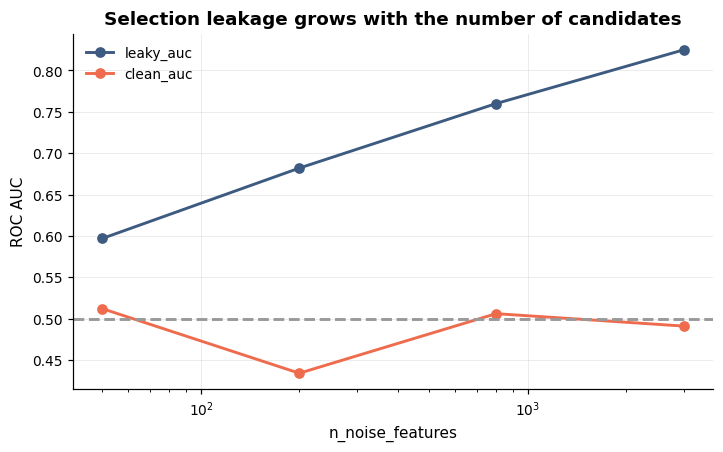

In [8]:
# The same effect, as a function of how many noise features you screen over.
sizes = [50, 200, 800, 3000]
rows = []
for p_i in sizes:
    Xi = pd.DataFrame(rng.normal(size=(n, p_i)))
    sel = SelectKBest(f_classif, k=20).fit(Xi, y_noise)
    lk = cross_val_score(LogisticRegression(max_iter=2000), Xi.iloc[:, sel.get_support()], y_noise, cv=5, scoring="roc_auc").mean()
    cl = cross_val_score(Pipeline([("s", SelectKBest(f_classif, k=20)), ("c", LogisticRegression(max_iter=2000))]), Xi, y_noise, cv=5, scoring="roc_auc").mean()
    rows.append({"n_noise_features": p_i, "leaky_auc": round(lk, 3), "clean_auc": round(cl, 3)})

leak_curve = pd.DataFrame(rows)
ax = leak_curve.plot(x="n_noise_features", y=["leaky_auc", "clean_auc"], marker="o", logx=True)
ax.axhline(0.5, ls="--", color="0.6")
ax.set_ylabel("ROC AUC"); ax.set_title("Selection leakage grows with the number of candidates")
leak_curve

## 5. Working with a fitted pipeline

You will need to reach inside one. Four idioms cover almost everything.

In [9]:
print("1. by name  :", type(model.named_steps["clf"]).__name__)
print("2. by index :", type(model[-1]).__name__)
print("3. slicing  :", model[:-1])          # a new Pipeline of the first n-1 steps
print("4. nested   :", type(model.named_steps["prep"].named_transformers_["cat"]).__name__)

1. by name  : LogisticRegression
2. by index : LogisticRegression
3. slicing  : Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fcc58781d10>),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='__missing__',
                 

In [10]:
# Slicing is how you inspect the intermediate matrix -- extremely useful for
# debugging "why does my model see 412 columns".
X_transformed = model[:-1].transform(X.head(3))
print("shape:", X_transformed.shape)
pd.DataFrame(X_transformed, columns=model[:-1].get_feature_names_out()).iloc[:, :6].round(3)

shape: (3, 37)


,num__age,num__employment_years,num__annual_income,num__loan_amount,num__term_months,num__interest_rate
0,-1.518,-0.975,-0.617,0.462,0.797,0.070
1,0.232,0.912,0.209,-0.203,-0.057,-0.754
2,1.148,0.889,0.554,0.105,0.797,-0.843


In [11]:
# `make_pipeline` / `make_column_transformer` auto-name the steps in lowercase.
# Convenient for quick work; explicit names are better for anything you will
# tune, because the parameter path depends on the name.
from sklearn.pipeline import make_pipeline

auto = make_pipeline(SimpleImputer(), StandardScaler(), LogisticRegression())
print(list(auto.named_steps))

['simpleimputer', 'standardscaler', 'logisticregression']


## 6. `"passthrough"` — turning a step off

Any step can be set to the string `"passthrough"`, which makes it the identity.
This is how you make "should I even use this step?" a tunable hyperparameter.

In [12]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

tunable = Pipeline([("scale", StandardScaler()), ("reduce", PCA()), ("clf", LogisticRegression(max_iter=2000))])

grid = GridSearchCV(
    tunable,
    param_grid=[
        {"reduce": ["passthrough"]},                 # no reduction at all
        {"reduce": [PCA()], "reduce__n_components": [5, 15]},
    ],
    cv=3,
    scoring="roc_auc",
)

from sklearn.datasets import load_breast_cancer

Xb, yb = load_breast_cancer(return_X_y=True, as_frame=True)
grid.fit(Xb, yb)
print("best:", grid.best_params_, f"-> {grid.best_score_:.4f}")
pd.DataFrame(grid.cv_results_)[["param_reduce", "param_reduce__n_components", "mean_test_score"]].round(4)

best: {'reduce': PCA(), 'reduce__n_components': 5} -> 0.9943


,param_reduce,param_reduce__n_components,mean_test_score
0,passthrough,NaN,0.9939
1,PCA(),5.0,0.9943
2,PCA(),15.0,0.9934


## 7. Caching: don't refit the expensive step 200 times

During a grid search over the classifier's hyperparameters, the preprocessing
is identical every time and gets recomputed every time. `memory=` caches
transformer fits to disk keyed on their inputs.

In [13]:
import shutil
import tempfile
from time import perf_counter

from sklearn.feature_selection import RFE
from sklearn.svm import SVC

cache_dir = tempfile.mkdtemp()
expensive = [("scale", StandardScaler()), ("select", RFE(SVC(kernel="linear"), n_features_to_select=10, step=3))]
param_grid = {"clf__C": [0.01, 0.1, 1, 10, 100]}

timings = {}
for label, mem in [("no cache", None), ("cached", cache_dir)]:
    pipe = Pipeline(expensive + [("clf", LogisticRegression(max_iter=2000))], memory=mem)
    t0 = perf_counter()
    GridSearchCV(pipe, param_grid, cv=3, n_jobs=1).fit(Xb, yb)
    timings[label] = perf_counter() - t0

print(f"no cache : {timings['no cache']:.2f}s")
print(f"cached   : {timings['cached']:.2f}s   ({timings['no cache'] / timings['cached']:.1f}x faster)")
shutil.rmtree(cache_dir)

no cache : 0.37s
cached   : 0.27s   (1.4x faster)


Caveat: the cache is keyed on the estimator's parameters and the input data,
so it only helps when the cached step's inputs really are identical across
candidates. It does nothing for a grid that varies the preprocessing itself,
and it costs disk. Use it when the preprocessing is expensive and the search
is over the final estimator.

## 8. The three things `Pipeline` cannot do

### (a) Resampling

`Pipeline` calls `fit_transform`, which must return the same number of rows.
SMOTE and random under-sampling change the row count, so they cannot be
sklearn `Pipeline` steps. Use `imblearn.pipeline.Pipeline`, which understands
a `fit_resample` method and — crucially — **only applies it during `fit`,
never during `predict`**. That distinction is the entire reason to use it
rather than resampling by hand.

In [14]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

try:
    Pipeline([("smote", SMOTE()), ("clf", LogisticRegression())]).fit(Xb, yb)
except TypeError as e:
    print("sklearn Pipeline + SMOTE ->", str(e).split("\n")[0][:110])

imb = ImbPipeline([("scale", StandardScaler()), ("smote", SMOTE(random_state=0)), ("clf", LogisticRegression(max_iter=2000))])
print("\nimblearn Pipeline -> works:", cross_val_score(imb, Xb, yb, cv=3, scoring="roc_auc").mean().round(4))

sklearn Pipeline + SMOTE -> All intermediate steps should be transformers and implement fit and transform or be the string 'passthrough' '

imblearn Pipeline -> works: 0.9921


### (b) Transforming `y`

Pipeline steps see `y` but never change it. To transform the target, wrap the
regressor in `TransformedTargetRegressor` (Module 02).

### (c) Branching / DAGs

A `Pipeline` is a chain. `FeatureUnion` and `ColumnTransformer` give you
parallel branches that reconverge, which covers most real needs. For a genuine
DAG — a step whose output feeds two different downstream branches that are
then combined differently — you are past what sklearn models and should reach
for a workflow tool (or restructure the problem).

In [15]:
from sklearn.pipeline import FeatureUnion

# FeatureUnion: several transformers on the SAME columns, concatenated.
# (ColumnTransformer: different transformers on DIFFERENT columns.)
from sklearn.preprocessing import SplineTransformer

union = FeatureUnion(
    [
        ("raw", "passthrough"),
        ("splines", SplineTransformer(n_knots=5)),
        ("pca", PCA(n_components=3)),
    ]
)
out = union.fit_transform(Xb.iloc[:, :4])
print("4 raw columns ->", out.shape[1], "columns:", 4, "+", 4 * (5 + 3 - 1), "+", 3)

4 raw columns -> 35 columns: 4 + 28 + 3


## 9. A reference-quality pipeline for tabular BFSI data

Everything so far, assembled. This is the shape to start from on a real
engagement — read it as a checklist rather than as code to copy blindly.

In [16]:
from sklearn.compose import make_column_selector as selector
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate


def build_tabular_pipeline(model="linear"):
    num = Pipeline(
        [
            ("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
        ]
    )
    cat = Pipeline(
        [
            ("impute", SimpleImputer(strategy="constant", fill_value="__missing__")),
            (
                "encode",
                OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30, sparse_output=False),
            ),
        ]
    )
    prep = ColumnTransformer(
        [
            ("num", num, selector(dtype_include=[np.number, "bool"])),
            ("cat", cat, selector(dtype_include=["object", "string", "category"])),
        ],
        remainder="drop",
        n_jobs=None,
    )
    clf = (
        LogisticRegression(max_iter=4000, C=0.3, class_weight="balanced")
        if model == "linear"
        else HistGradientBoostingClassifier(random_state=0, learning_rate=0.06, max_iter=300, early_stopping=True)
    )
    return Pipeline([("prep", prep), ("clf", clf)])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
summary = []
for kind in ["linear", "boosted"]:
    res = cross_validate(
        build_tabular_pipeline(kind), X, y, cv=cv,
        scoring=["roc_auc", "average_precision"], n_jobs=-1, return_train_score=True,
    )
    summary.append(
        {
            "model": kind,
            "test_auc": f"{res['test_roc_auc'].mean():.4f} ± {res['test_roc_auc'].std():.4f}",
            "train_auc": f"{res['train_roc_auc'].mean():.4f}",
            "test_ap": f"{res['test_average_precision'].mean():.4f}",
            "fit_s": f"{res['fit_time'].mean():.2f}",
        }
    )
pd.DataFrame(summary).set_index("model")

,test_auc,train_auc,test_ap,fit_s
model,,,,
linear,0.7736 ± 0.0101,0.7824,0.4258,0.09
boosted,0.7616 ± 0.0075,0.8875,0.4078,0.27


In [17]:
# The HTML repr is the fastest way to check the wiring is what you meant.
build_tabular_pipeline("boosted")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

---
## Exercises

### Exercise 3.1 — Trace the calls

Extend the `Loud` transformer to also record the *number of rows* it sees, and
use it to instrument a 3-fold `cross_val_score` on a 3-step pipeline. Print a
tally: how many times was each step fitted, and on how many rows? Confirm the
arithmetic matches what you would predict from `n_splits` and the fold sizes.

In [18]:
# Your code here.

### Exercise 3.2 — The `remainder` trap

Build a `ColumnTransformer` with `remainder="passthrough"` on the full credit
frame *including* `application_id`, and fit a `HistGradientBoostingClassifier`.
What happens? Then repeat with `application_id` converted to an integer by
stripping the prefix. Report the AUC and explain what the model has learned.
(This is a real failure mode: sequential IDs correlate with time, and time
correlates with the target.)

In [19]:
# Your code here.

### Exercise 3.3 — Quantify five leaks

For each of the following, build a leaky version and a pipeline version, and
report the gap on the credit data with 5-fold CV:

1. Scaling before the split.
2. `SelectKBest(k=10)` before the split.
3. `TargetEncoder` fitted on the full data.
4. Removing outliers (rows beyond 3σ on any numeric column) before the split.
5. SMOTE applied to the whole dataset before the split.

Rank them by how much they inflate the score. Which one is the most dangerous,
and is "most dangerous" the same as "largest gap"?

In [20]:
# Your code here.

### Exercise 3.4 — Feature-name forensics

Write `explain_feature(pipeline, name)` that, given a fitted pipeline and one
of its output feature names, returns a dict describing: the source column, the
`ColumnTransformer` branch, every transformer applied in order, and — for
one-hot columns — which category it represents. Test it on five names from
your reference pipeline, including one indicator column and one
`infrequent_sklearn` column.

In [21]:
# Your code here.

### Exercise 3.5 — Design a pipeline for the fraud data

The `card_fraud` dataset has: a timestamp, a high-cardinality `card_id`,
several numerics with very different scales, a handful of categoricals, and a
0.5% positive rate. Design and justify a preprocessing pipeline for it. Your
answer should address, explicitly: what you do with `timestamp`, what you do
with `card_id`, whether you scale, whether you resample, and why each choice
is defensible. Then implement it and get a cross-validated average precision.
(Deliberately open-ended — the justification is the deliverable, not the
number.)

In [22]:
# Your code here.

---
## Takeaways

- `fit` on the training path, `transform` only on the predict path. That
  asymmetry *is* the leakage guarantee.
- `ColumnTransformer` + `make_column_selector` is the standard shape for
  heterogeneous tables. Prefer `remainder="drop"`: it fails safe.
- Any decision made by looking at all the data before splitting is a leak —
  selection, encoding, outlier removal, resampling, threshold choice.
- `model[:-1].transform(X)` and `get_feature_names_out()` are your debugging
  tools; learn them before you need them.
- `"passthrough"` makes "use this step at all?" tunable. `memory=` stops you
  refitting expensive preprocessing hundreds of times.
- Resampling needs `imblearn.pipeline.Pipeline`; target transforms need
  `TransformedTargetRegressor`.

**Next:** Module 04 — cross-validation, and the several ways a split can lie
to you even when the pipeline is clean.